# Data loading

In [2]:
import os
input_files = [
    "combined_data_1.txt",
    "combined_data_2.txt",
    "combined_data_3.txt",
    "combined_data_4.txt"
]
output_file = open("netflix_cleaned.csv", "w")
output_file.write("user_id,movie_id,rating,date\n")
for file in input_files:
    with open(file, "r") as f:
        movie_id = None
        
        for line in f:
            if line.endswith(":\n"):
                movie_id = line.strip().replace(":", "")
            else:
                user_id, rating, date = line.strip().split(",")
                output_file.write(f"{user_id},{movie_id},{rating},{date}\n")
output_file.close()
print("Finished converting files.")

Finished converting files.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score,mean_squared_error, mean_absolute_error

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from warnings import filterwarnings

import joblib

np.random.seed(42)

filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [10]:
Movies = pd.read_csv(
    "netflix_cleaned.csv",
    dtype={
        "user_id": "int32",
        "movie_id": "int16",
        "rating": "int8"
    },
    parse_dates=["date"]
)

In [11]:
Movies.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [12]:
titles_raw = pd.read_csv(
    "movie_titles.csv",
    encoding="latin1",
    header=None,
    names=["line"],
    sep="\t"
)

titles = titles_raw["line"].str.split(",", n=2, expand=True)
titles.columns = ["movie_id", "year", "title"]

titles["movie_id"] = titles["movie_id"].astype("int16")
titles["year"] = pd.to_numeric(titles["year"], errors="coerce").astype("Int16")
titles["title"] = titles["title"].astype("string")

titles.head()


,movie_id,year,title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


In [13]:
df = pd.merge(Movies, titles, on='movie_id', how='inner')

In [14]:
df.head()

,user_id,movie_id,rating,date,year,title
0,1488844,1,3,2005-09-06,2003,Dinosaur Planet
1,822109,1,5,2005-05-13,2003,Dinosaur Planet
2,885013,1,4,2005-10-19,2003,Dinosaur Planet
3,30878,1,4,2005-12-26,2003,Dinosaur Planet
4,823519,1,3,2004-05-03,2003,Dinosaur Planet


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100480507 entries, 0 to 100480506
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   user_id   int32         
 1   movie_id  int16         
 2   rating    int8          
 3   date      datetime64[ns]
 4   year      Int16         
 5   title     string        
dtypes: Int16(1), datetime64[ns](1), int16(1), int32(1), int8(1), string(1)
memory usage: 2.4 GB


In [16]:
print('Shape:', df.shape)
print(df.columns)

Shape: (100480507, 6)
Index(['user_id', 'movie_id', 'rating', 'date', 'year', 'title'], dtype='object')


In [17]:
print(df.isnull().sum())

user_id       0
movie_id      0
rating        0
date          0
year        965
title         0
dtype: int64


In [18]:
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 0


## Sampling

In [19]:
netflix_df = df.sample(n=1000000, random_state=42).copy()

print('Sample shape:', netflix_df.shape)
netflix_df.head()

Sample shape: (1000000, 6)


,user_id,movie_id,rating,date,year,title
87800315,404578,15582,4,2005-10-26,2002,Sweet Home Alabama
36770798,636396,6510,4,2004-08-05,1998,A Bug's Life
87357564,2258880,15500,4,2005-06-15,2001,Gilmore Girls: Season 2
81468281,1574865,14621,2,2004-08-26,2001,Shrek (Full-screen)
21872551,237063,4123,4,2004-01-26,1998,Patch Adams


user_id      0
movie_id     0
rating       0
date         0
year        13
title        0
dtype: int64


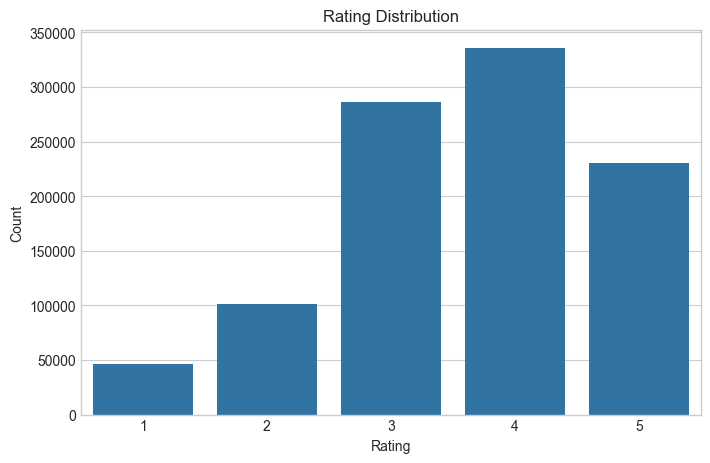

In [20]:
print(netflix_df.isnull().sum())

plt.figure(figsize=(8, 5))
sns.countplot(data=netflix_df, x='rating')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [21]:
# Task 1.5 - Drop unnecessary columns
# 1. Drop date and year because they are not needed for the baseline model
# 2. Keep user_id, movie_id, rating, and title

netflix_df = netflix_df.drop(columns=['date', 'year'], errors='ignore').copy()

print('Modeling dataframe shape:', netflix_df.shape)
netflix_df.head()


Modeling dataframe shape: (1000000, 4)


,user_id,movie_id,rating,title
87800315,404578,15582,4,Sweet Home Alabama
36770798,636396,6510,4,A Bug's Life
87357564,2258880,15500,4,Gilmore Girls: Season 2
81468281,1574865,14621,2,Shrek (Full-screen)
21872551,237063,4123,4,Patch Adams


In [22]:
global_mean = netflix_df['rating'].mean()

user_mean = netflix_df.groupby('user_id')['rating'].mean()
movie_mean = netflix_df.groupby('movie_id')['rating'].mean()

print('Global Mean Rating:', global_mean)

Global Mean Rating: 3.604112


# Model training

In [23]:
X = netflix_df[['user_id', 'movie_id', 'title']]
y = netflix_df['rating']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1000000, 3)
y shape: (1000000,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (800000, 3)
X_test: (200000, 3)
y_train: (800000,)
y_test: (200000,)


In [25]:
# Task 2.3 - Rebuild train and test dataframes
# This keeps your X_train and y_train style, but makes recommender calculations easier

train_df = X_train.copy()
train_df['rating'] = y_train.values

test_df = X_test.copy()
test_df['rating'] = y_test.values

train_df.head()


,user_id,movie_id,title,rating
72218393,1314834,13058,Backdraft,4
12990715,1477316,2462,"Planes, Trains and Automobiles",3
23708181,203278,4432,The Italian Job,5
12477127,331432,2391,Along Came Polly,3
26410154,1754507,4914,White Noise,4


In [26]:
global_mean = train_df['rating'].mean()

user_mean = train_df.groupby('user_id')['rating'].mean()
movie_mean = train_df.groupby('movie_id')['rating'].mean()

user_bias = user_mean - global_mean
movie_bias = movie_mean - global_mean

print('Global Mean Rating:', global_mean)
print('Number of users:', user_bias.shape[0])
print('Number of movies:', movie_bias.shape[0])

Global Mean Rating: 3.60406375
Number of users: 266164
Number of movies: 15666


## Predict

In [27]:
def predict_rating(user_id, movie_id):
    u_bias = user_bias.get(user_id, 0)
    m_bias = movie_bias.get(movie_id, 0)

    pred = global_mean + u_bias + m_bias
    pred = np.clip(pred, 1, 5)

    return pred

In [28]:
test_df['predicted_rating'] = [
    predict_rating(user_id, movie_id)
    for user_id, movie_id in zip(test_df['user_id'], test_df['movie_id'])
]

test_df[['user_id', 'movie_id', 'title', 'rating', 'predicted_rating']].head()


,user_id,movie_id,title,rating,predicted_rating
34682331,2556987,6223,Point Break,3,3.393809
9939789,487509,1931,Eye of the Needle,4,1.000000
63440719,1972971,11544,The Witches of Eastwick,4,1.000000
42183112,2638077,7485,Frantic,4,3.280702
16200313,908037,3148,The English Patient,3,2.633391


# Evaluation

In [29]:
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_df['predicted_rating']))
mae = mean_absolute_error(test_df['rating'], test_df['predicted_rating'])

print('############ Testing Eval #############')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')


############ Testing Eval #############
RMSE: 1.0946
MAE: 0.8455


## Ploting

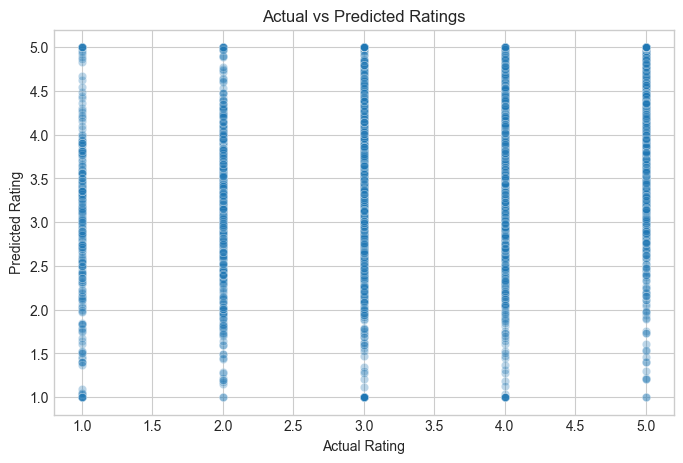

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=test_df['rating'].sample(5000, random_state=42),
    y=test_df['predicted_rating'].sample(5000, random_state=42),
    alpha=0.3
)
plt.title('Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()


# Test unseen data

In [31]:
movie_titles = netflix_df[['movie_id', 'title']].drop_duplicates()

def recommend_movies(user_id, top_n=10):
    watched_movies = netflix_df[netflix_df['user_id'] == user_id]['movie_id'].unique()

    unseen_movies = movie_titles[
        ~movie_titles['movie_id'].isin(watched_movies)
    ].copy()

    unseen_movies['predicted_rating'] = unseen_movies['movie_id'].apply(
        lambda movie_id: predict_rating(user_id, movie_id)
    )

    recommendations = unseen_movies.sort_values(
        by='predicted_rating',
        ascending=False
    ).head(top_n)

    return recommendations


### Sample user

In [32]:
sample_user = netflix_df['user_id'].iloc[0]

print('User ID:', sample_user)
recommend_movies(sample_user, top_n=10)


User ID: 404578


,movie_id,title,predicted_rating
77363953,14076,Stephen Lynch: Live at the El Rey,5.0
56176292,10251,Samurai 7,5.0
98769330,17430,Combat Vietnam: To Hell and Beyond,5.0
87891594,15587,Mythical Detective Loki Ragnarok,5.0
19329499,3677,Sesame Street: Let's Make Music,5.0
58956119,10829,Masters of Poker: Phil Hellmuth's Million Doll...,5.0
95794565,16973,The Idiots,5.0
41188733,7265,Swoon,5.0
37862940,6725,Connections 3,5.0
36606099,6489,Miami Guns,5.0


# Save model

In [33]:
model_objects = {
    'global_mean': global_mean,
    'user_bias': user_bias,
    'movie_bias': movie_bias,
    'movie_titles': movie_titles
}

joblib.dump(model_objects, 'netflix_recommendation_model.joblib')

print('Saved model to netflix_recommendation_model.joblib')


Saved model to netflix_recommendation_model.joblib


# Hybrid Feedback-Aware SVD Recommender


In [34]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from pathlib import Path


In [35]:
# Task 4.2 - Prepare data for SVD matrix factorization
# 1. Keep user_id, movie_id, rating, and title
# 2. Use a smaller sample so training stays practical

svd_df = netflix_df[['user_id', 'movie_id', 'rating', 'title']].dropna().copy()

svd_sample_size = 200000
if svd_df.shape[0] > svd_sample_size:
    svd_df = svd_df.sample(n=svd_sample_size, random_state=42).copy()

svd_df['user_id'] = svd_df['user_id'].astype('int32')
svd_df['movie_id'] = svd_df['movie_id'].astype('int32')
svd_df['rating'] = svd_df['rating'].astype('float32')

print('SVD dataframe shape:', svd_df.shape)
print('Unique users:', svd_df['user_id'].nunique())
print('Unique movies:', svd_df['movie_id'].nunique())
svd_df.head()


SVD dataframe shape: (200000, 4)
Unique users: 127825
Unique movies: 11466


,user_id,movie_id,rating,title
34682331,2556987,6223,3.0,Point Break
9939789,487509,1931,4.0,Eye of the Needle
63440719,1972971,11544,4.0,The Witches of Eastwick
42183112,2638077,7485,4.0,Frantic
16200313,908037,3148,3.0,The English Patient


In [36]:
# Task 4.3 - Split SVD train and test data
# 1. Define X and y
# 2. Split into train and test sets

svd_X = svd_df[['user_id', 'movie_id', 'title']]
svd_y = svd_df['rating']

svd_X_train, svd_X_test, svd_y_train, svd_y_test = train_test_split(
    svd_X,
    svd_y,
    test_size=0.20,
    random_state=42
)

svd_train_df = svd_X_train.copy()
svd_train_df['rating'] = svd_y_train.values

svd_test_df = svd_X_test.copy()
svd_test_df['rating'] = svd_y_test.values

print('SVD train shape:', svd_train_df.shape)
print('SVD test shape:', svd_test_df.shape)


SVD train shape: (160000, 4)
SVD test shape: (40000, 4)


In [37]:
# Task 4.4 - Encode users and movies
# 1. Encode user_id into user_idx
# 2. Encode movie_id into movie_idx
# 3. Build lookup dictionaries for fast prediction

user_encoder_svd = LabelEncoder()
movie_encoder_svd = LabelEncoder()

user_encoder_svd.fit(svd_df['user_id'])
movie_encoder_svd.fit(svd_df['movie_id'])

svd_train_df['user_idx'] = user_encoder_svd.transform(svd_train_df['user_id'])
svd_train_df['movie_idx'] = movie_encoder_svd.transform(svd_train_df['movie_id'])

svd_test_df['user_idx'] = user_encoder_svd.transform(svd_test_df['user_id'])
svd_test_df['movie_idx'] = movie_encoder_svd.transform(svd_test_df['movie_id'])

n_users = len(user_encoder_svd.classes_)
n_movies = len(movie_encoder_svd.classes_)

user_id_to_idx_svd = {
    int(user_id): int(idx)
    for idx, user_id in enumerate(user_encoder_svd.classes_)
}

movie_id_to_idx_svd = {
    int(movie_id): int(idx)
    for idx, movie_id in enumerate(movie_encoder_svd.classes_)
}

user_id_set_svd = set(user_id_to_idx_svd.keys())
movie_id_set_svd = set(movie_id_to_idx_svd.keys())

print('Encoded users:', n_users)
print('Encoded movies:', n_movies)


Encoded users: 127825
Encoded movies: 11466


In [38]:
# Task 4.5 - Train SVD matrix factorization model
# 1. Build sparse user-movie rating matrix
# 2. Center ratings around the global mean
# 3. Train TruncatedSVD

global_mean_svd = svd_train_df['rating'].mean()

rating_matrix = csr_matrix(
    (
        svd_train_df['rating'] - global_mean_svd,
        (svd_train_df['user_idx'], svd_train_df['movie_idx'])
    ),
    shape=(n_users, n_movies)
)

svdModel = TruncatedSVD(n_components=30, random_state=42)
user_factors = svdModel.fit_transform(rating_matrix)
movie_factors = svdModel.components_.T

print('User factors shape:', user_factors.shape)
print('Movie factors shape:', movie_factors.shape)
print('Explained variance:', svdModel.explained_variance_ratio_.sum())


User factors shape: (127825, 30)
Movie factors shape: (11466, 30)
Explained variance: 0.056149565


In [39]:
# Task 4.6 - Create SVD prediction function
# Predict rating using user and movie latent vectors


def predict_svd_rating(user_id, movie_id):
    user_id = int(user_id)
    movie_id = int(movie_id)

    if user_id not in user_id_set_svd:
        return global_mean_svd
    if movie_id not in movie_id_set_svd:
        return global_mean_svd

    user_idx = user_id_to_idx_svd[user_id]
    movie_idx = movie_id_to_idx_svd[movie_id]

    pred = global_mean_svd + np.dot(user_factors[user_idx], movie_factors[movie_idx])
    pred = np.clip(pred, 1, 5)

    return pred


In [40]:
# Task 4.7 - Predict and evaluate SVD model
# Display: RMSE and MAE on SVD test data

svd_test_df['svd_predicted_rating'] = [
    predict_svd_rating(user_id, movie_id)
    for user_id, movie_id in zip(svd_test_df['user_id'], svd_test_df['movie_id'])
]

svd_rmse = np.sqrt(mean_squared_error(svd_test_df['rating'], svd_test_df['svd_predicted_rating']))
svd_mae = mean_absolute_error(svd_test_df['rating'], svd_test_df['svd_predicted_rating'])

print('############ SVD Testing Eval #############')
print(f'RMSE: {svd_rmse:.4f}')
print(f'MAE: {svd_mae:.4f}')

svd_test_df[['user_id', 'movie_id', 'title', 'rating', 'svd_predicted_rating']].head()


############ SVD Testing Eval #############
RMSE: 1.0896
MAE: 0.9139


,user_id,movie_id,title,rating,svd_predicted_rating
74235450,1469603,13458,Virtuosity,3.0,3.602358
61209889,1534248,11172,Kundun,3.0,3.602356
2794984,506924,499,Under Suspicion,3.0,3.602356
100100825,1844442,17672,My Dog Skip,4.0,3.602355
62209857,1024468,11307,The Barbarian Invasions,3.0,3.602356


In [41]:
# Task 4.8 - Generate SVD candidate recommendations
# 1. Remove movies the user already rated
# 2. Score unseen movies using SVD
# 3. Return top candidate movies

svd_movie_titles = svd_df[['movie_id', 'title']].drop_duplicates().copy()

movie_id_set_svd = set(movie_encoder_svd.classes_)


def get_svd_recommendations(user_id, top_n=20):
    watched_movies = svd_df[svd_df['user_id'] == user_id]['movie_id'].unique()

    candidate_movies = svd_movie_titles[
        ~svd_movie_titles['movie_id'].isin(watched_movies)
    ].copy()

    candidate_movies = candidate_movies[
        candidate_movies['movie_id'].isin(movie_id_set_svd)
    ].copy()

    candidate_movies['svd_score'] = candidate_movies['movie_id'].apply(
        lambda movie_id: predict_svd_rating(user_id, movie_id)
    )

    return candidate_movies.sort_values(by='svd_score', ascending=False).head(top_n)


In [42]:
# Task 4.9 - Create feedback table structure
# This simulates feedback that will later come from the website database

feedback_df = pd.DataFrame(columns=[
    'user_id',
    'movie_id',
    'title',
    'rating',
    'review_text',
    'sentiment_label'
])

feedback_df.head()


,user_id,movie_id,title,rating,review_text,sentiment_label


In [43]:
# Task 4.10 - Create feedback helper functions
# 1. Convert rating to sentiment
# 2. Add feedback row


def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'


def add_user_feedback(feedback_df, user_id, movie_id, rating, review_text):
    movie_title = svd_movie_titles[svd_movie_titles['movie_id'] == movie_id]['title'].values[0]
    sentiment_label = rating_to_sentiment(rating)

    new_feedback = pd.DataFrame({
        'user_id': [user_id],
        'movie_id': [movie_id],
        'title': [movie_title],
        'rating': [rating],
        'review_text': [review_text],
        'sentiment_label': [sentiment_label]
    })

    feedback_df = pd.concat([feedback_df, new_feedback], ignore_index=True)
    return feedback_df


In [44]:
# Task 4.11 - Re-rank recommendations using user feedback
# 1. Exclude movies already reviewed by the user
# 2. Boost movies that received good feedback
# 3. Adjust recommendations using the user's average feedback rating


def rerank_with_feedback(user_id, candidate_recommendations, feedback_df, top_n=10):
    recs = candidate_recommendations.copy()

    if feedback_df.empty:
        recs['final_score'] = recs['svd_score']
        return recs.sort_values(by='final_score', ascending=False).head(top_n)

    user_feedback = feedback_df[feedback_df['user_id'] == user_id]
    reviewed_movies = user_feedback['movie_id'].unique()

    recs = recs[~recs['movie_id'].isin(reviewed_movies)].copy()

    movie_feedback_mean = feedback_df.groupby('movie_id')['rating'].mean()
    user_feedback_bias = 0

    if not user_feedback.empty:
        user_feedback_bias = user_feedback['rating'].mean() - 3

    recs['feedback_movie_score'] = recs['movie_id'].map(movie_feedback_mean).fillna(3)
    recs['final_score'] = (
        recs['svd_score']
        + 0.25 * (recs['feedback_movie_score'] - 3)
        + 0.10 * user_feedback_bias
    )

    return recs.sort_values(by='final_score', ascending=False).head(top_n)


In [45]:
# Task 4.12 - Test hybrid recommendations
# Generate SVD candidates, then re-rank them with feedback

sample_user = svd_df['user_id'].iloc[0]

candidate_recommendations = get_svd_recommendations(sample_user, top_n=20)
hybrid_recommendations = rerank_with_feedback(
    sample_user,
    candidate_recommendations,
    feedback_df,
    top_n=10
)

print('Sample user:', sample_user)
hybrid_recommendations


Sample user: 2556987


,movie_id,title,svd_score,final_score
82173136,14691,The Matrix,3.605277,3.605277
43388356,7635,Anchorman: The Legend of Ron Burgundy,3.604057,3.604057
55660661,10168,The League of Extraordinary Gentlemen,3.603799,3.603799
6682431,1307,S.W.A.T.,3.603573,3.603573
59556386,10947,The Incredibles,3.603283,3.603283
14446024,2782,Braveheart,3.603205,3.603205
91245947,16242,Con Air,3.603047,3.603047
80934403,14550,The Shawshank Redemption: Special Edition,3.603039,3.603039
21249823,3962,Finding Nemo (Widescreen),3.603014,3.603014
70929168,12870,Schindler's List,3.603010,3.603010


# NLP Sentiment Model From ACL IMDb Reviews


In [46]:
# Task 5.1 - Load ACL IMDb dataset paths
# Dataset folder: aclImdb/train and aclImdb/test

imdb_path = Path('aclImdb')

print('ACL IMDb path exists:', imdb_path.exists())
print('Train positive path exists:', (imdb_path / 'train' / 'pos').exists())
print('Train negative path exists:', (imdb_path / 'train' / 'neg').exists())


ACL IMDb path exists: True
Train positive path exists: True
Train negative path exists: True


In [47]:
# Task 5.2 - Create function to load IMDb reviews
# 1. Read positive reviews
# 2. Read negative reviews
# 3. Return dataframe with review_text and sentiment_label


def load_imdb_split(split_name, max_files_per_class=None):
    rows = []

    for folder_name, sentiment_label in [('pos', 'Positive'), ('neg', 'Negative')]:
        folder_path = imdb_path / split_name / folder_name
        files = sorted(folder_path.glob('*.txt'))

        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        for file_path in files:
            review_text = file_path.read_text(encoding='utf-8', errors='ignore')
            rows.append({
                'review_text': review_text,
                'sentiment_label': sentiment_label,
                'split': split_name
            })

    return pd.DataFrame(rows)


In [48]:
# Task 5.3 - Load train and test reviews
# Change max_files_per_class to None if you want to train on the full ACL IMDb dataset

imdb_train_df = load_imdb_split('train', max_files_per_class=5000)
imdb_test_df = load_imdb_split('test', max_files_per_class=2000)

print('IMDb train shape:', imdb_train_df.shape)
print('IMDb test shape:', imdb_test_df.shape)
print()
print('Training label distribution:')
print(imdb_train_df['sentiment_label'].value_counts())

imdb_train_df.head()


IMDb train shape: (10000, 3)
IMDb test shape: (4000, 3)

Training label distribution:
sentiment_label
Positive    5000
Negative    5000
Name: count, dtype: int64


,review_text,sentiment_label,split
0,Bromwell High is a cartoon comedy. It ran at t...,Positive,train
1,Homelessness (or Houselessness as George Carli...,Positive,train
2,Brilliant over-acting by Lesley Ann Warren. Be...,Positive,train
3,This is easily the most underrated film inn th...,Positive,train
4,This is not the typical Mel Brooks film. It wa...,Positive,train


In [49]:
# Task 5.4 - Define NLP X and y
# 1. Review text is X
# 2. Sentiment label is y

X_nlp_train = imdb_train_df['review_text']
y_nlp_train = imdb_train_df['sentiment_label']

X_nlp_test = imdb_test_df['review_text']
y_nlp_test = imdb_test_df['sentiment_label']

print('X_nlp_train:', X_nlp_train.shape)
print('X_nlp_test:', X_nlp_test.shape)


X_nlp_train: (10000,)
X_nlp_test: (4000,)


In [50]:
# Task 5.5 - Train NLP sentiment model
# 1. Tokenize reviews with TF-IDF
# 2. Train Logistic Regression classifier

nlpModel = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_features=50000
    )),
    ('lgModel', LogisticRegression(max_iter=1000, random_state=42))
])

nlpModel.fit(X_nlp_train, y_nlp_train)

print('NLP model trained successfully')


NLP model trained successfully


In [51]:
# Task 5.6 - Evaluate NLP sentiment model
# Display: accuracy and classification report

y_nlp_pred = nlpModel.predict(X_nlp_test)

print('############ NLP Testing Eval #############')
print(f"Accuracy: {accuracy_score(y_nlp_test, y_nlp_pred):.4f}")
print(classification_report(y_nlp_test, y_nlp_pred))


############ NLP Testing Eval #############
Accuracy: 0.8852
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      2000
    Positive       0.89      0.88      0.88      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



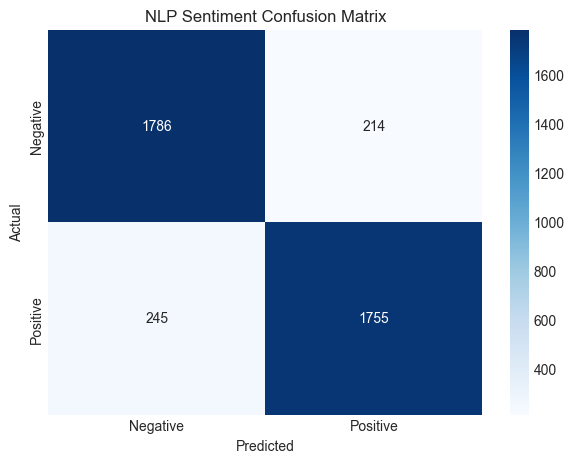

In [52]:
# Task 5.7 - Plot NLP confusion matrix
# Display: positive vs negative classification performance

nlp_labels = ['Negative', 'Positive']
nlp_cm = confusion_matrix(y_nlp_test, y_nlp_pred, labels=nlp_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(nlp_cm, annot=True, fmt='d', cmap='Blues', xticklabels=nlp_labels, yticklabels=nlp_labels)
plt.title('NLP Sentiment Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [53]:
# Task 5.8 - Test NLP model on new user review
# This is the same type of review the website user will write after watching a movie

new_review = pd.Series([
    'I felt excited while watching it and the ending was very satisfying.',
    'I was bored and the movie felt too slow for me.'
])

new_review_predictions = nlpModel.predict(new_review)

display(pd.DataFrame({
    'review_text': new_review,
    'predicted_sentiment': new_review_predictions
}))


,review_text,predicted_sentiment
0,I felt excited while watching it and the endin...,Negative
1,I was bored and the movie felt too slow for me.,Negative


In [54]:
# Task 5.9 - Save NLP sentiment model
# The website can load this model to classify written user feedback

joblib.dump(nlpModel, 'netflix_review_nlp_model.joblib', compress=3)

print('Saved NLP model to netflix_review_nlp_model.joblib')


Saved NLP model to netflix_review_nlp_model.joblib


# Save Final Hybrid Model


In [55]:
# Task 6.1 - Save hybrid SVD feedback-aware recommender
# 1. Save SVD movie factors for feedback-based user profiles
# 2. Save movie bias for cold-start recommendations
# 3. Save movie titles for the website

svd_movie_bias = svd_train_df.groupby('movie_id')['rating'].mean() - global_mean_svd
svd_user_bias = svd_train_df.groupby('user_id')['rating'].mean() - global_mean_svd

hybrid_model_objects = {
    'model_type': 'hybrid_svd_feedback_reranker',
    'global_mean': float(global_mean_svd),
    'movie_titles': svd_movie_titles,
    'movie_bias': svd_movie_bias,
    'user_bias': svd_user_bias,
    'svd_model': svdModel,
    'movie_factors': movie_factors.astype('float32'),
    'movie_id_to_idx': movie_id_to_idx_svd,
    'n_components': 30
}

joblib.dump(hybrid_model_objects, 'netflix_recommendation_model.joblib', compress=3)

print('Saved hybrid recommender to netflix_recommendation_model.joblib')
print('Model type:', hybrid_model_objects['model_type'])


Saved hybrid recommender to netflix_recommendation_model.joblib
Model type: hybrid_svd_feedback_reranker


In [56]:
# Final Note
# Main implemented model: SVD / Matrix Factorization + feedback re-ranking
# NLP model: TF-IDF + Logistic Regression trained on ACL IMDb reviews
# Future work: Deep Reinforcement Learning or LightGCN with feedback signals

print('Final recommendation model: netflix_recommendation_model.joblib')
print('Final NLP feedback model: netflix_review_nlp_model.joblib')


Final recommendation model: netflix_recommendation_model.joblib
Final NLP feedback model: netflix_review_nlp_model.joblib
